# 🧠 Case Study : Predict Customer Cancellation

 [Case Study Link](https://docs.google.com/document/d/1DrkN30mmBapBX146OvhscGHtAnjqkWkO7scGCNnLqvc/edit#heading=h.wpciijalbsdh)

<div class="alert alert-block alert-success">
      
 👨‍🏫 **Vikesh K**      
  

</div>

<div class="alert alert-block alert-danger">
    
# OH Agenda 📝
    
We will cover:

* Cancellation Prediction
    * EDA with respect to model building
    * Data Prep
    * Model Building

     
 </div>

##  <font color= darkred> Import modules and data </font>

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# data viz
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("fivethirtyeight") # styling the charts

import warnings
warnings.filterwarnings('ignore')
plt.rcParams["image.cmap"] = 'Blues'

**Load Data**

In [2]:
url = 'https://raw.githubusercontent.com/vkoul/data/main/misc/hotel_bookings.csv'

df = pd.read_csv(url)

##  <font color= darkred> Data Inspection</font>🔍📊

### <font color= darkred> Numerical inspection and summaries </font>

**Data Inspect**

In [3]:
df.sample(6)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
38173,1,0,1,0,Not Selected,0,Room_Type 1,4,2019,3,6,Online,0,0,0,62.4,0,Not_Canceled
43154,2,0,0,3,Meal Plan 1,0,Room_Type 4,18,2018,5,10,Online,0,0,0,146.0,1,Not_Canceled
28625,2,1,1,2,Meal Plan 1,0,Room_Type 1,81,2018,10,21,Online,0,0,0,135.0,0,Canceled
3219,3,0,1,3,Meal Plan 1,0,Room_Type 4,88,2018,10,10,Online,0,0,0,151.2,0,Canceled
34834,1,0,1,1,Meal Plan 2,0,Room_Type 1,301,2018,7,30,Offline,0,0,0,90.0,0,Not_Canceled
14873,3,0,0,3,Meal Plan 1,0,Room_Type 1,77,2018,5,17,Online,0,0,0,159.3,0,Canceled


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56926 entries, 0 to 56925
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          56926 non-null  int64  
 1   no_of_children                        56926 non-null  int64  
 2   no_of_weekend_nights                  56926 non-null  int64  
 3   no_of_week_nights                     56926 non-null  int64  
 4   type_of_meal_plan                     56926 non-null  str    
 5   required_car_parking_space            56926 non-null  int64  
 6   room_type_reserved                    56926 non-null  str    
 7   lead_time                             56926 non-null  int64  
 8   arrival_year                          56926 non-null  int64  
 9   arrival_month                         56926 non-null  int64  
 10  arrival_date                          56926 non-null  int64  
 11  market_segment_type       

### Learner Hypothesis

**Data Quality**
  

*  Missing values
*  Duplicates
*  Outliers
*  Skewed Sets

**EDA** \ **Business Hypothesis**

* Lead time is short, less likely to have a cancellation than longer lead time
* Is that special request column relevant to cancellations
* Correaltion amongst the components
* Guest History- No of previous cancelattions-
* Overlapping bookings
* Ratio of cancelled and non-cancelled

**Pre-processing for ML**
* data with different scale- numeric
* Turn strings into numeric data - encoding
* Imputation - Simple Imputations or ML based imputations

**Tuning**
* neighbors


**Evaluation**

* Accuracy
* Confusion Matrix
* FN and FP - The cost implications of the wrong predictions
* Lift Analysis


**Adding the components of date**

In [5]:
df["complete_arrival_date"] = pd.to_datetime(
    dict(year=df["arrival_year"], month=df["arrival_month"], day=df["arrival_date"]),
    errors="coerce"
)


In [6]:
df.head(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,complete_arrival_date
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56926 entries, 0 to 56925
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          56926 non-null  int64         
 1   no_of_children                        56926 non-null  int64         
 2   no_of_weekend_nights                  56926 non-null  int64         
 3   no_of_week_nights                     56926 non-null  int64         
 4   type_of_meal_plan                     56926 non-null  str           
 5   required_car_parking_space            56926 non-null  int64         
 6   room_type_reserved                    56926 non-null  str           
 7   lead_time                             56926 non-null  int64         
 8   arrival_year                          56926 non-null  int64         
 9   arrival_month                         56926 non-null  int64         
 10  arrival_d

In [8]:
pd.to_datetime(df['complete_arrival_date'])

0       2017-10-02
1       2018-11-06
2       2018-02-28
3       2018-05-20
4       2019-07-13
           ...    
56921   2019-06-15
56922   2019-05-15
56923   2018-04-21
56924   2019-04-28
56925   2018-12-30
Name: complete_arrival_date, Length: 56926, dtype: datetime64[us]

In [9]:
df.iloc[4108,]

no_of_adults                                      2
no_of_children                                    0
no_of_weekend_nights                              1
no_of_week_nights                                 5
type_of_meal_plan                       Meal Plan 1
required_car_parking_space                        0
room_type_reserved                      Room_Type 1
lead_time                                       104
arrival_year                                   2018
arrival_month                                     2
arrival_date                                     29
market_segment_type                          Online
repeated_guest                                    1
no_of_previous_cancellations                      1
no_of_previous_bookings_not_canceled              0
avg_price_per_room                            61.43
no_of_special_requests                            0
booking_status                             Canceled
complete_arrival_date                           NaT
Name: 4108, 

In [10]:
df = df.query('complete_arrival_date != "2018 2 29"').copy()

In [11]:
df['complete_arrival_date'] = pd.to_datetime(df['complete_arrival_date']).copy()

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56926 entries, 0 to 56925
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          56926 non-null  int64         
 1   no_of_children                        56926 non-null  int64         
 2   no_of_weekend_nights                  56926 non-null  int64         
 3   no_of_week_nights                     56926 non-null  int64         
 4   type_of_meal_plan                     56926 non-null  str           
 5   required_car_parking_space            56926 non-null  int64         
 6   room_type_reserved                    56926 non-null  str           
 7   lead_time                             56926 non-null  int64         
 8   arrival_year                          56926 non-null  int64         
 9   arrival_month                         56926 non-null  int64         
 10  arrival_d

In [13]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,complete_arrival_date
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,2018-02-28
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2018-05-20
4,3,0,0,3,Not Selected,0,Room_Type 1,277,2019,7,13,Online,0,0,0,89.10,2,Canceled,2019-07-13


##   <font color= darkred> Data Quality Check </font>

**Missing values check**

In [14]:
df.isna().sum()

no_of_adults                             0
no_of_children                           0
no_of_weekend_nights                     0
no_of_week_nights                        0
type_of_meal_plan                        0
required_car_parking_space               0
room_type_reserved                       0
lead_time                                0
arrival_year                             0
arrival_month                            0
arrival_date                             0
market_segment_type                      0
repeated_guest                           0
no_of_previous_cancellations             0
no_of_previous_bookings_not_canceled     0
avg_price_per_room                       0
no_of_special_requests                   0
booking_status                           0
complete_arrival_date                   37
dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56926 entries, 0 to 56925
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          56926 non-null  int64         
 1   no_of_children                        56926 non-null  int64         
 2   no_of_weekend_nights                  56926 non-null  int64         
 3   no_of_week_nights                     56926 non-null  int64         
 4   type_of_meal_plan                     56926 non-null  str           
 5   required_car_parking_space            56926 non-null  int64         
 6   room_type_reserved                    56926 non-null  str           
 7   lead_time                             56926 non-null  int64         
 8   arrival_year                          56926 non-null  int64         
 9   arrival_month                         56926 non-null  int64         
 10  arrival_d

In [16]:
df.duplicated().sum()

np.int64(14350)

In [17]:
df.shape

(56926, 19)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df['booking_status'].value_counts(normalize = True).round(2)

booking_status
Not_Canceled    0.66
Canceled        0.34
Name: proportion, dtype: float64

**Cleaning the booking_status column**

In [21]:
df['booking_status'] = df['booking_status'].replace({'Not_Canceled': 0,  'Canceled': 1})

In [22]:
df['booking_status'].value_counts(normalize = True).round(2)

booking_status
0    0.66
1    0.34
Name: proportion, dtype: float64

In [23]:
df['booking_status'].mean()

np.float64(0.34026211950394586)

**Extracting the relevant values from the date column**

In [24]:
df['year'] = df['complete_arrival_date'].dt.year

df['month'] = df['complete_arrival_date'].dt.month

df['month_name'] = df['complete_arrival_date'].dt.month_name()

df['day'] = df['complete_arrival_date'].dt.day

df['day_name'] = df['complete_arrival_date'].dt.day_name()

In [25]:
df[["year", "month", "month_name", "day", "day_name", "complete_arrival_date"]].head()

,year,month,month_name,day,day_name,complete_arrival_date
0,2017.0,10.0,October,2.0,Monday,2017-10-02
1,2018.0,11.0,November,6.0,Tuesday,2018-11-06
2,2018.0,2.0,February,28.0,Wednesday,2018-02-28
3,2018.0,5.0,May,20.0,Sunday,2018-05-20
4,2019.0,7.0,July,13.0,Saturday,2019-07-13


##   <font color= darkred> EDA </font>

### Univariate Analysis

year
2017.0    0.122271
2018.0    0.315286
2019.0    0.425012
Name: booking_status, dtype: object

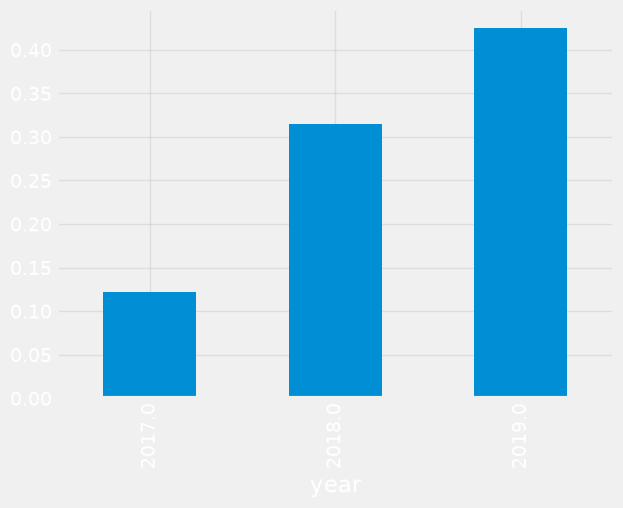

In [26]:
display(df.groupby('year')['booking_status'].mean())

df.groupby('year')['booking_status'].mean().plot(kind = 'bar');

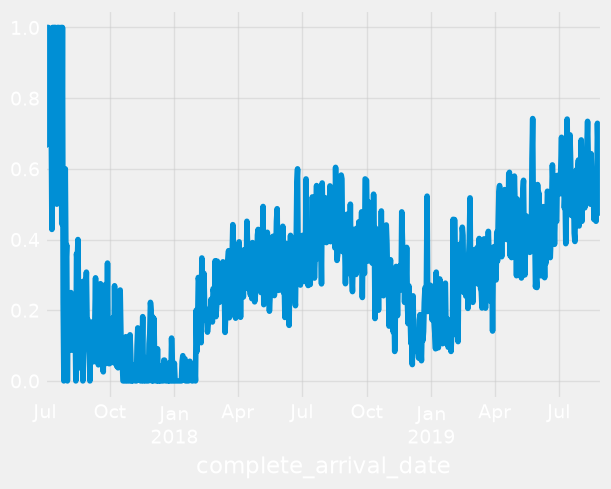

In [27]:
df.groupby(['complete_arrival_date'])['booking_status'].mean().plot(kind = 'line');

<Axes: xlabel='complete_arrival_date'>

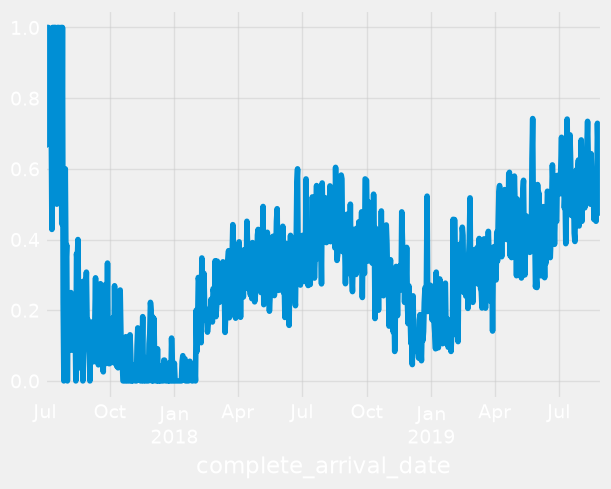

In [28]:
df.groupby(['complete_arrival_date'])['booking_status'].mean().plot(kind='line')

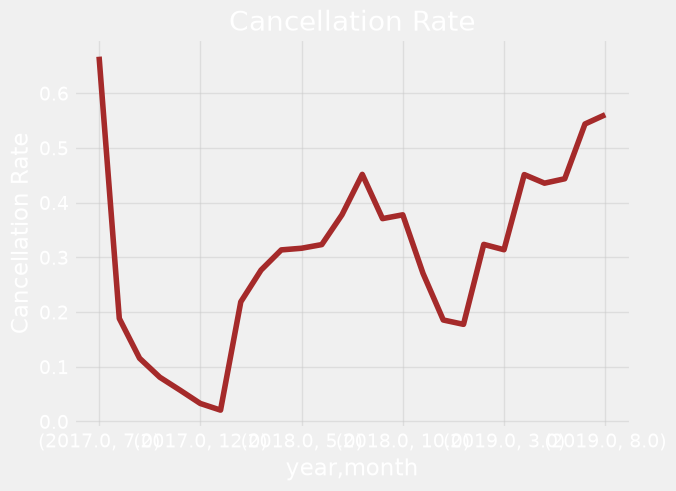

In [29]:
df.groupby(['year' ,'month'])['booking_status'].mean().plot(kind = 'line', color = "brown", title = "Cancellation Rate", ylabel = "Cancellation Rate");

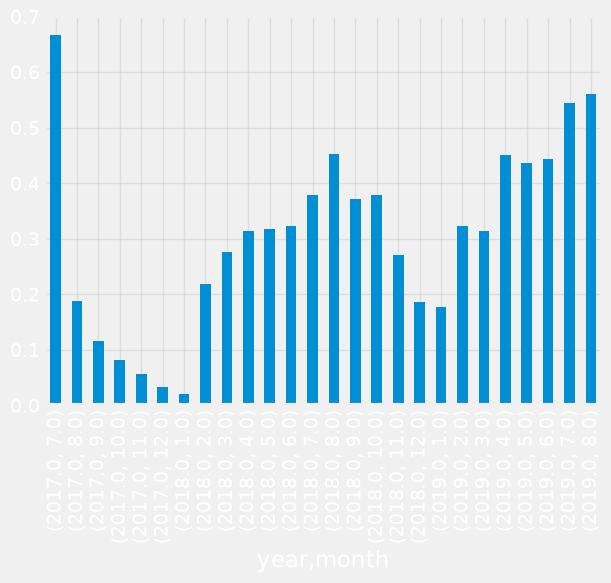

In [30]:
df.groupby(['year' ,'month'])['booking_status'].mean().plot(kind = 'bar');

In [31]:
monthly = df.groupby(['year', 'month'], as_index = False)['booking_status'].mean()
monthly.head().round(2)

,year,month,booking_status
0,2017.0,7.0,0.666667
1,2017.0,8.0,0.18818
2,2017.0,9.0,0.115505
3,2017.0,10.0,0.080808
4,2017.0,11.0,0.057143


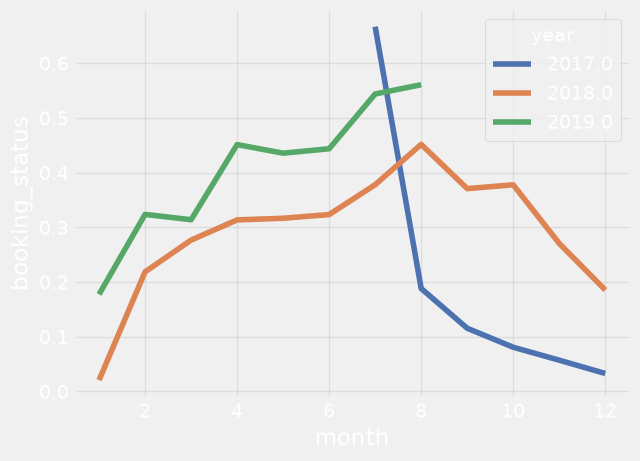

In [32]:
sns.lineplot(data = monthly, x = 'month', y = 'booking_status', hue = 'year', palette = 'deep');

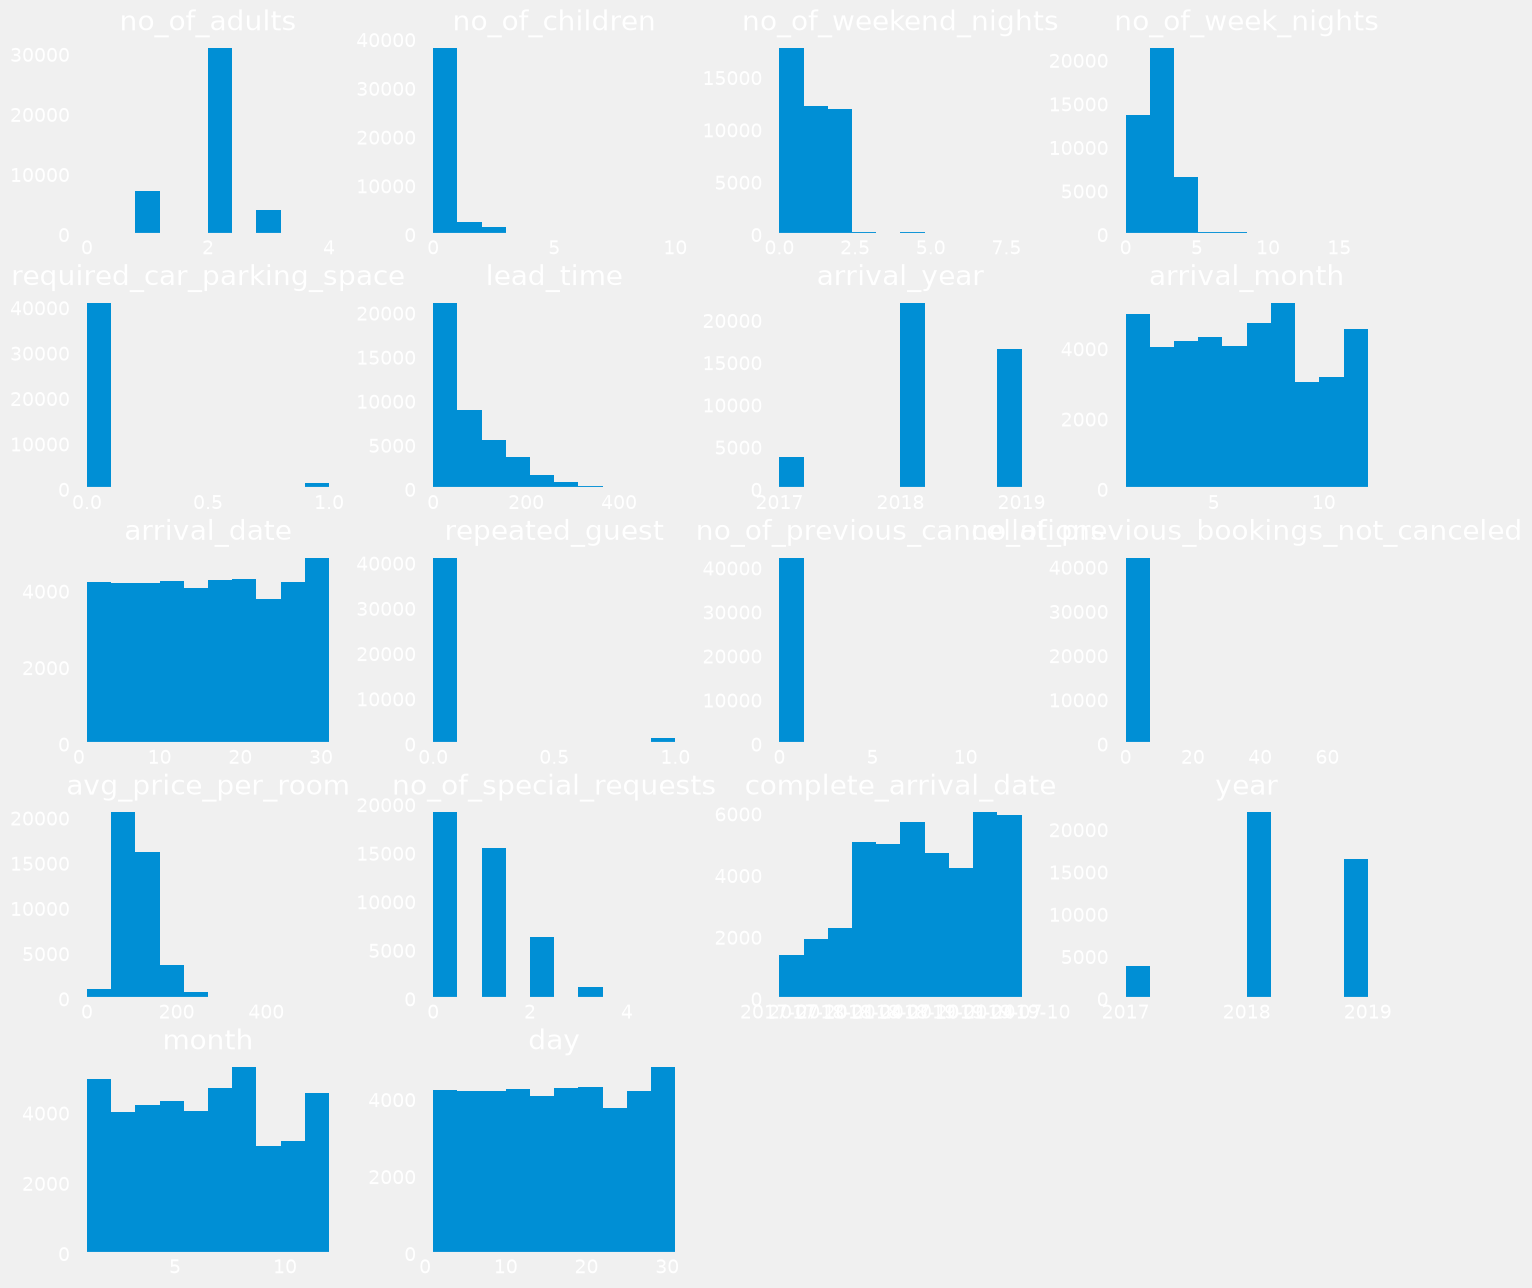

In [33]:
df.hist(figsize= (15,15), grid = False);

In [34]:
df.describe().round(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,complete_arrival_date,year,month,day
count,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42576.00,42541,42541.00,42541.00,42541.00
mean,1.92,0.14,0.90,2.32,0.03,77.32,2018.30,6.37,15.68,0.03,0.03,0.22,112.38,0.77,2018-10-13 20:45:11.699301,2018.30,6.37,15.67
min,0.00,0.00,0.00,0.00,0.00,0.00,2017.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,2017-07-01 00:00:00,2017.00,1.00,1.00
25%,2.00,0.00,0.00,1.00,0.00,16.00,2018.00,4.00,8.00,0.00,0.00,0.00,85.50,0.00,2018-05-12 00:00:00,2018.00,4.00,8.00
50%,2.00,0.00,1.00,2.00,0.00,53.00,2018.00,6.00,16.00,0.00,0.00,0.00,107.00,1.00,2018-10-15 00:00:00,2018.00,6.00,16.00
75%,2.00,0.00,2.00,3.00,0.00,118.00,2019.00,9.00,23.00,0.00,0.00,0.00,135.00,1.00,2019-04-14 00:00:00,2019.00,9.00,23.00
max,4.00,10.00,8.00,17.00,1.00,521.00,2019.00,12.00,31.00,1.00,13.00,72.00,540.00,5.00,2019-08-31 00:00:00,2019.00,12.00,31.00
std,0.53,0.46,0.89,1.52,0.18,77.28,0.63,3.05,8.81,0.17,0.36,2.24,40.87,0.84,NaN,0.63,3.05,8.81


### Bivariate Analysis

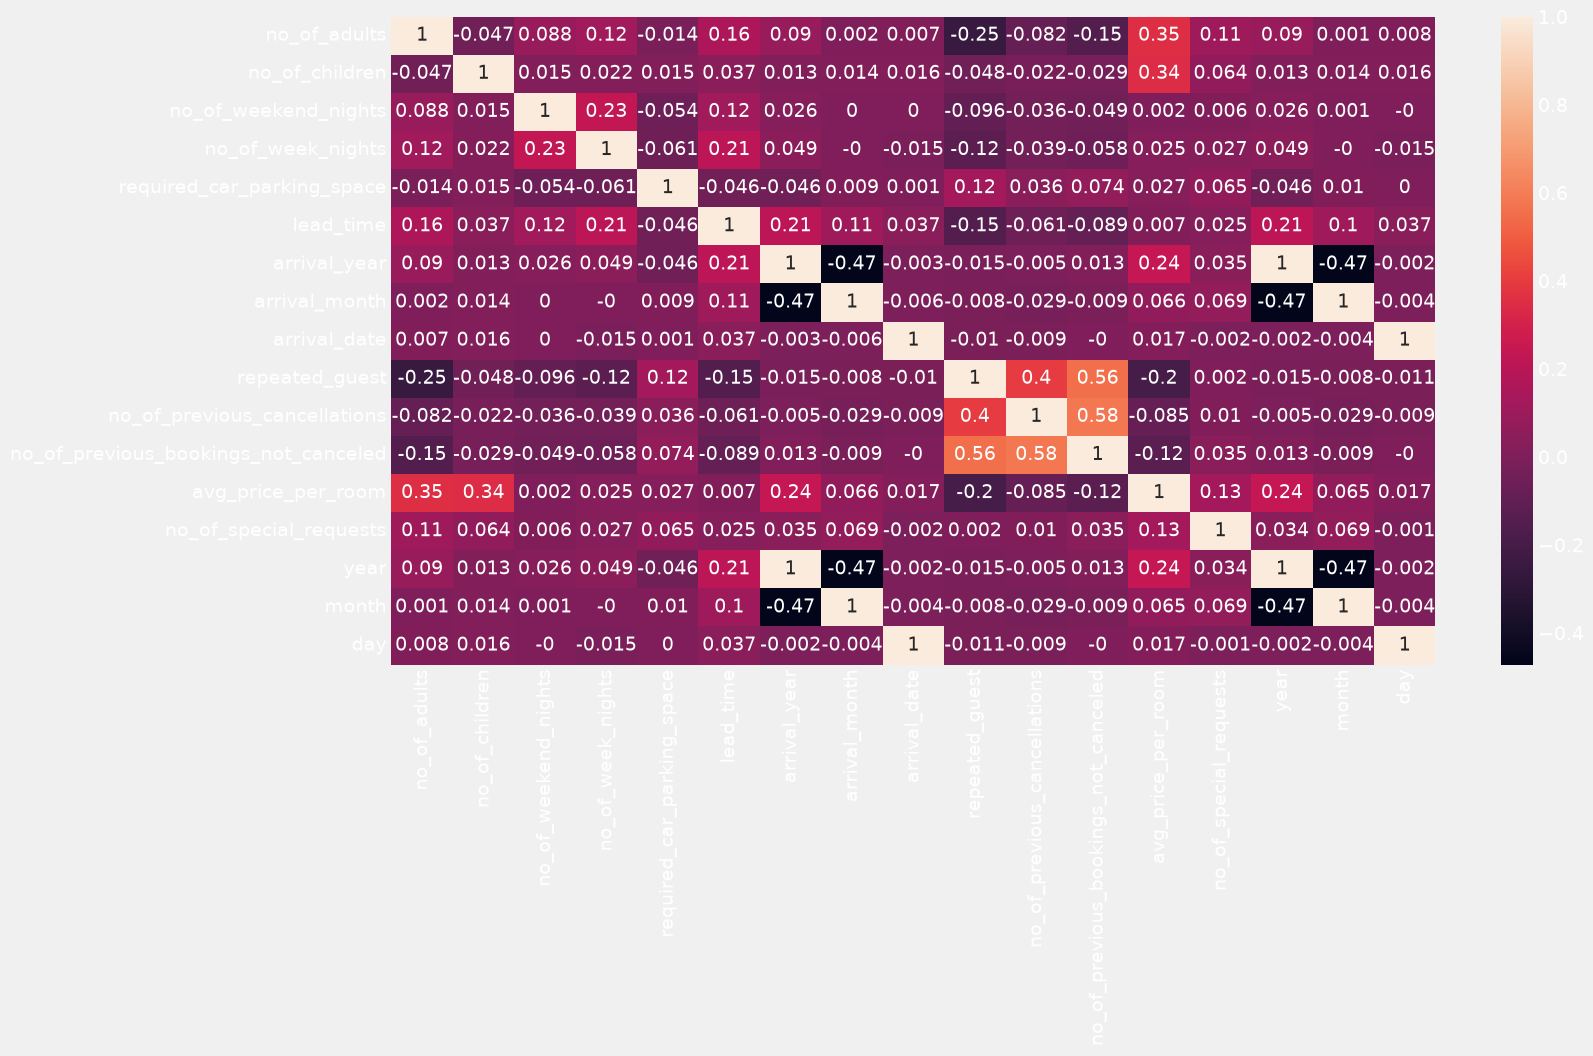

In [35]:
corr = df.corr(numeric_only = True).round(3)

plt.figure(figsize= (15,8))
sns.heatmap(corr, annot= True);

### Numerical

booking_status
0     54.00
1    122.53
Name: lead_time, dtype: float64

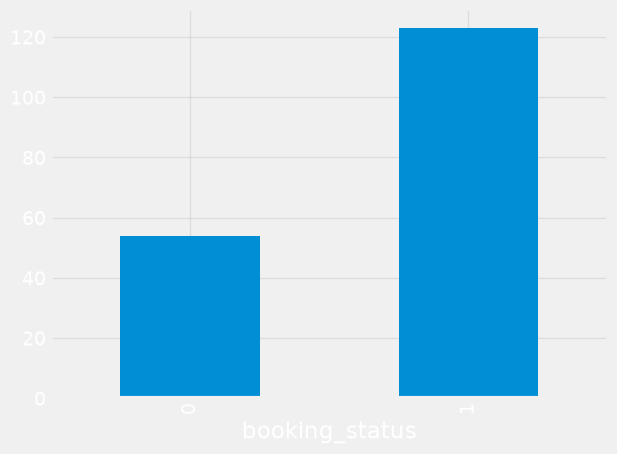

In [36]:
display(df.groupby('booking_status')['lead_time'].mean().round(2))

df.groupby('booking_status')['lead_time'].mean().round().plot(kind = "bar");

booking_status
0    106.49
1    123.79
Name: avg_price_per_room, dtype: float64

booking_status
0     99.45
1    117.00
Name: avg_price_per_room, dtype: float64

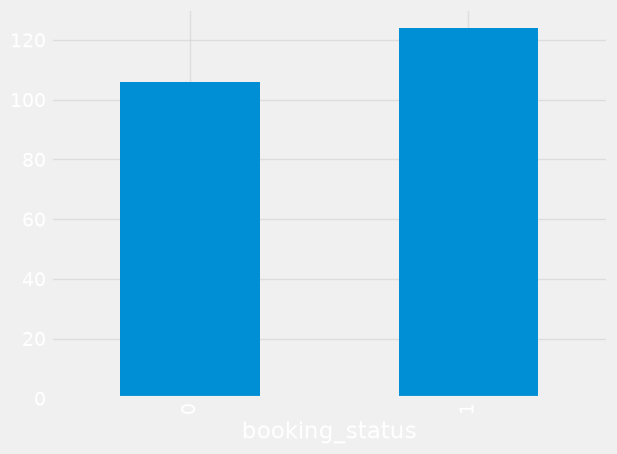

In [37]:
display(df.groupby('booking_status')['avg_price_per_room'].mean().round(2))
display(df.groupby('booking_status')['avg_price_per_room'].median().round(2))


df.groupby('booking_status')['avg_price_per_room'].mean().round().plot(kind = "bar");

### Categorical values and Booking Status

In [38]:
df.select_dtypes(['object']).columns.tolist()

['type_of_meal_plan',
 'room_type_reserved',
 'market_segment_type',
 'booking_status',
 'month_name',
 'day_name']

In [39]:
cat_list =  df.select_dtypes(['object']).columns.tolist()
cat_list

['type_of_meal_plan',
 'room_type_reserved',
 'market_segment_type',
 'booking_status',
 'month_name',
 'day_name']

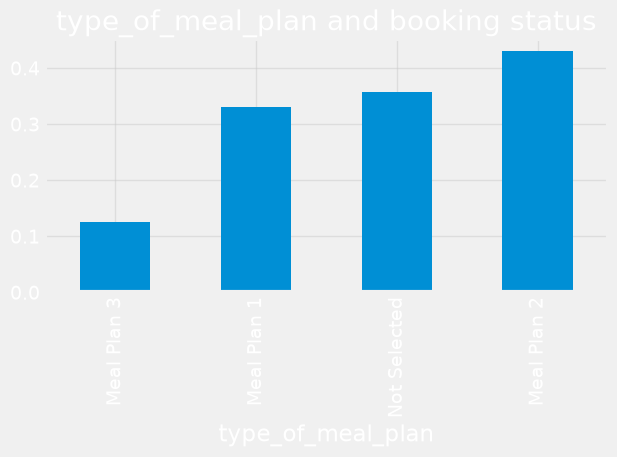

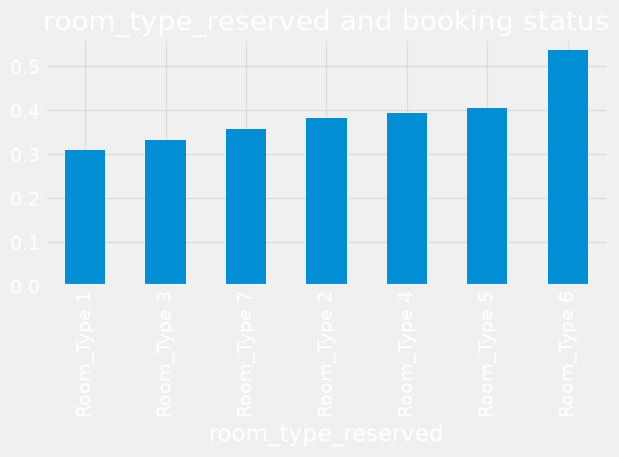

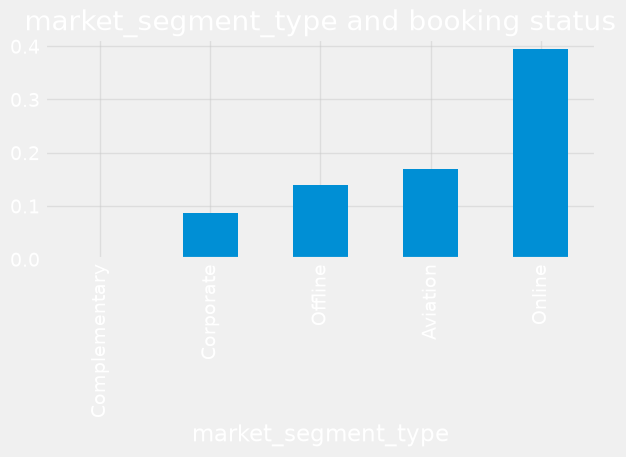

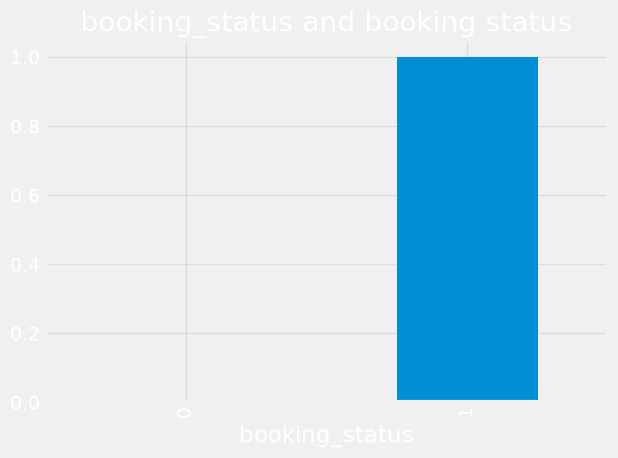

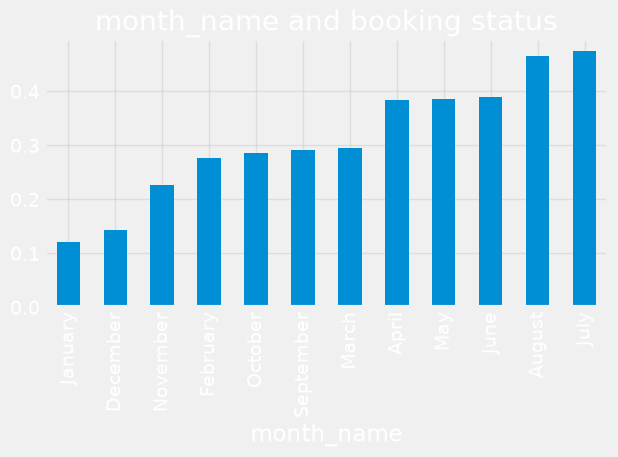

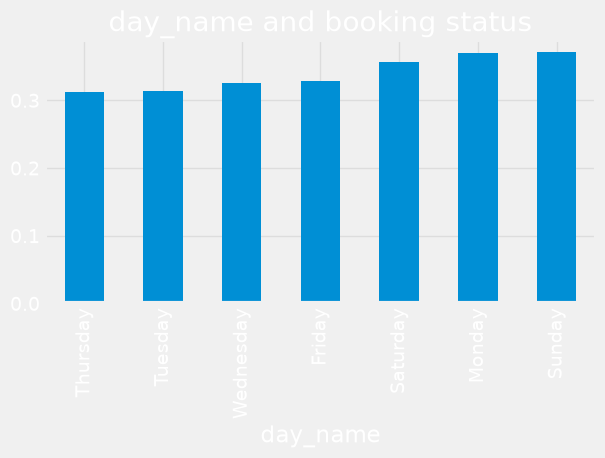

In [40]:
for cat in cat_list:
    df.groupby(cat)['booking_status'].mean().sort_values().plot(kind = 'bar', title = f'{cat} and booking status');
    plt.tight_layout()
    plt.show();

#### Crosstab View

In [41]:
for cat in cat_list:
    display(
        pd.crosstab(df[cat], df['booking_status'], normalize='columns') # one can use index for horizontal calculation
        .style
        .format('{:.0%}')
        .background_gradient(axis='index')
    )


AttributeError: The '.style' accessor requires jinja2

#### Cross Tab Visualized

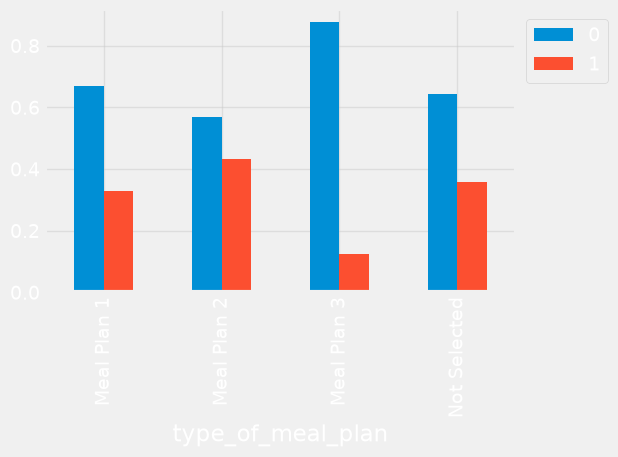

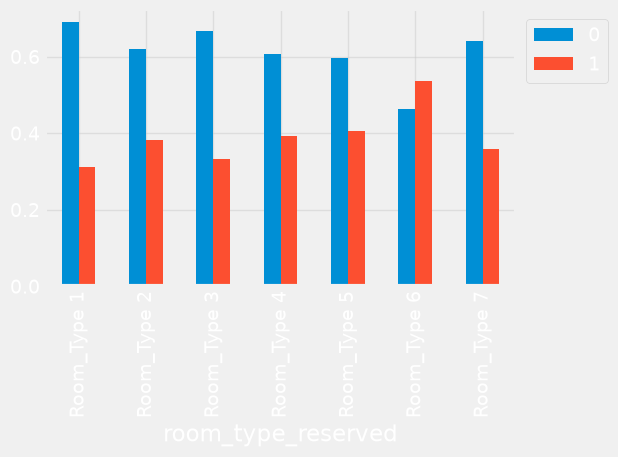

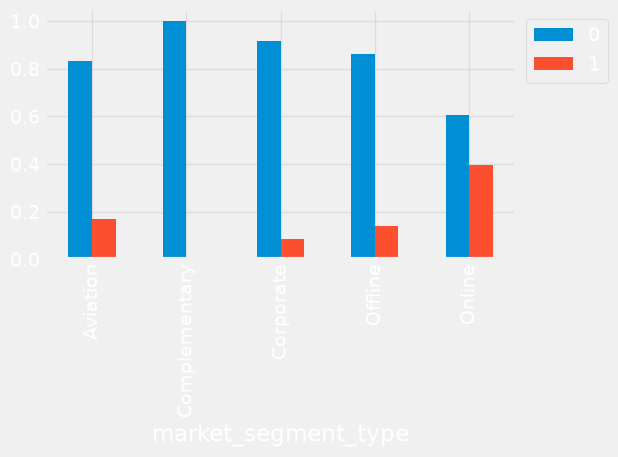

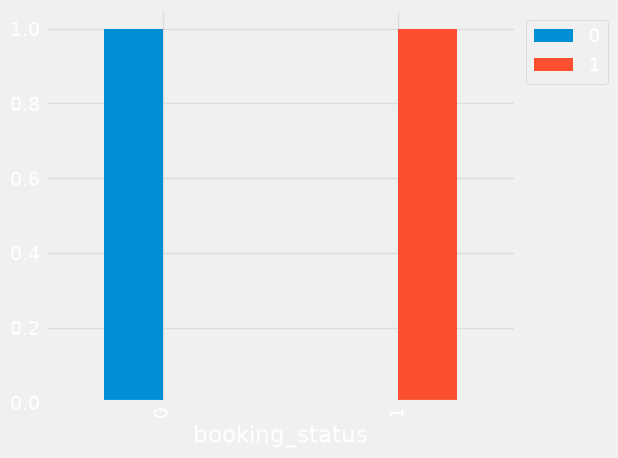

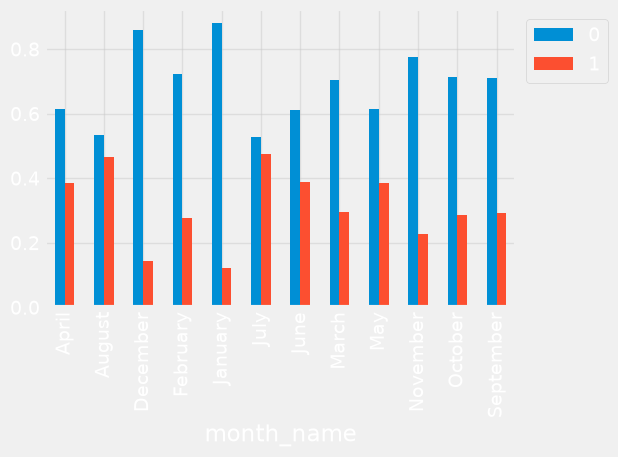

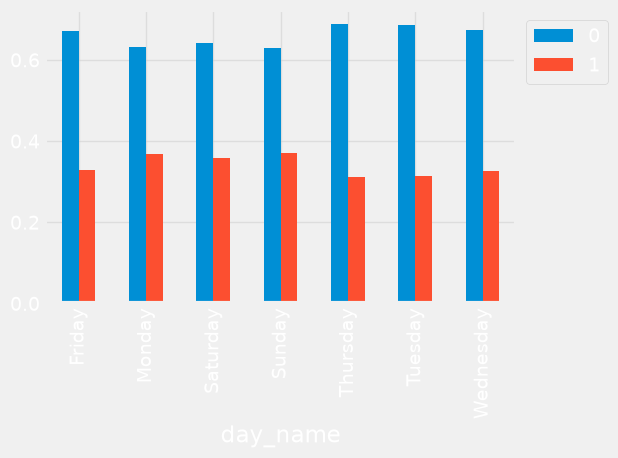

In [42]:
for cat in cat_list:
    ax = pd.crosstab(df[cat], df['booking_status'], normalize='index').plot(kind="bar")

    # Moving the legend and using 'loc' ensures it doesn't overlap the bars
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show();

##  <font color= darkred> Data Prep for Modeling </font>

**We will drop the columns not required for the analysis**

In [43]:
df.drop(columns = ['month_name', 'day_name', 'year', 'month', 'day', 'complete_arrival_date'], inplace = True)

### Train-Test Split

**This should always happen before the treatment of the Numerical and the Categorical data, otherwise data leakage happens, especially in the case of standardisation**

In [44]:
# data prep
from sklearn.model_selection import train_test_split

In [45]:
# splitting the data
X = df.drop(columns = 'booking_status')
y = df['booking_status']

In [46]:
# # doing train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [47]:
print("x_train: ", X_train.shape)
print("y_train: ", y_train.shape)


print("\n")

print("x_test: ", X_test.shape)
print("y_test: ", y_test.shape)

display(X_train.head())
display(y_train.head())


x_train:  (34060, 17)
y_train:  (34060,)


x_test:  (8516, 17)
y_test:  (8516,)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
29432,2,0,0,2,Meal Plan 1,0,Room_Type 1,10,2017,9,11,Online,0,0,0,128.50,2
35636,2,0,2,2,Not Selected,0,Room_Type 1,43,2018,11,25,Online,0,0,0,74.80,0
50277,2,0,2,7,Not Selected,0,Room_Type 1,187,2018,8,26,Online,0,0,0,84.72,0
46242,3,1,2,2,Meal Plan 1,0,Room_Type 7,114,2019,7,8,Online,0,0,0,221.49,2
35678,2,0,2,2,Meal Plan 1,0,Room_Type 1,172,2018,6,4,Online,0,0,0,100.30,1


29432    0
35636    1
50277    1
46242    1
35678    1
Name: booking_status, dtype: object

### Pre-Processing

**We will do the whole operation using `sklearn` methods:**

*   `OneHotEncoder` for One hot encoding of the Categorical data
*   `StandardScaler` for the pre-processing of the numerical columns.

**We will make use of the `ColumnTransformer` to do the right mapping. It determines which columns get which pre-processin done.**

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [49]:
len(df.columns)

18

In [50]:
num_cols = ['no_of_adults', 'no_of_children', 'lead_time', 'no_of_weekend_nights', 'avg_price_per_room', 'no_of_week_nights', 'no_of_special_requests',
            'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled']

cat_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

print(len(num_cols) + len(cat_cols))

# mapping the pre-processing method
ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
        # ,("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        , ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output= False), cat_cols) # to be used only for Pandas output
    ],  remainder="passthrough"
)

# ensure output is pandas rather than numpy array
ct.set_output(transform="pandas")

12


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

⚠️**To have the Pandas output, you would need to have a dense output from the OneHotEncoder() rather than a sparse one, which is the default.Otherwise, it wont work**

💡**A sparse matrix stores only the non-zeros:memory roughly proportional to number of 1s efficient for many models, hence its the default of OHE**


⚠️**Should avoid Pandas output incase of high cardinality, many categorical values, tree ensemble method or neural network methods. Use it for debugging, Feature importance plots, learning**

💡**Can do the pandas output within pipeline as well**
  `pipe.set_output(transform="pandas")`



**Transformation on the train and test data**

In [51]:
# fit and transforming using Train
X_train_transformed = ct.fit_transform(X_train)

# transformin the test
X_test_transformed  = ct.transform(X_test)

In [52]:
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

## <font color= darkred> Model building </font> 💥⚡

### Dummy classifier model using [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)

In [53]:
from sklearn.dummy import DummyClassifier

In [54]:
dummy = DummyClassifier()

In [55]:
dummy.fit(X_train_transformed, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.66,0.34]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](30,)","['num__no_of_adults','num__no_of_children','num__lead_time',..., 'remainder__arrival_month','remainder__arrival_date', 'remainder__repeated_guest']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,30
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [56]:
print(f"The accuracy score of the model for Train is {dummy.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {dummy.score(X_test_transformed, y_test):.1%}")

ValueError: Classification metrics can't handle a mix of unknown and binary targets

### K-NN Model using [KNNClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
knn = KNeighborsClassifier()

# fit the model
knn.fit(X_train_transformed, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [59]:
print(f"The accuracy score of the model for Train is {knn.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {knn.score(X_test_transformed, y_test):.1%}")

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### Logistic Regression model using [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [60]:
from sklearn.linear_model import LogisticRegression

In [61]:
lr = LogisticRegression()

# fit the model
lr.fit(X_train_transformed, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [62]:
print(f"The accuracy score of the model for Train is {lr.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {lr.score(X_test_transformed, y_test):.1%}")

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

### Decision Trees model using [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)


In [63]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
dt = DecisionTreeClassifier(max_depth = None)

# fit the model
dt.fit(X_train_transformed, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [65]:
print(f"The accuracy score of the model for Train is {dt.score(X_train_transformed, y_train):.1%}")
print(f"The accuracy score of the model for Test is {dt.score(X_test_transformed, y_test):.1%}")

AttributeError: 'DecisionTreeClassifier' object has no attribute 'tree_'

### Follow-up Tasks

* Tune the K-NN model and note down the improvements you see. Can you achieve 85% accuracy on the test data?

* Compare the cost implications of FP and FN across the models. Assume a cost for FN and FP.

* As we cover other models in the upcoming module, revisit this case study and build the tuned versions of the models that you study